# 01:  Track Analysis
**Q1**: Are all four storms matched within ±15 kt at peak `USA_WIND`?  
**Q2**: How does Vmax change as a function of hours-to-impact in the final 96 h?  

**Prerequisite**: run `00_download_ibtracs.py` first (`data/ibtracs/storms_filtered.csv` must exist).  
**Outputs**: `data/ibtracs/{storm}_track.csv` for each available storm.

## 1:  Setup

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# make utils importable when notebook runs from scripts/
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils import IBTRACS_DIR, FIG_DIR, STORM_ORDER, STORMS, haversine, ensure_dirs

ensure_dirs()
FILTERED_CSV = os.path.join(IBTRACS_DIR, 'storms_filtered.csv')
assert os.path.exists(FILTERED_CSV), f'Not found: {FILTERED_CSV}:  run 00_download_ibtracs.py first.'
print('Filtered CSV found:', FILTERED_CSV)

Filtered CSV found: /home/sharperace/geog_1.02_final_proj/data/ibtracs/storms_filtered.csv


## 2:  Load filtered IBTrACS data

In [2]:
df_all = pd.read_csv(FILTERED_CSV, low_memory=False)
df_all['ISO_TIME'] = pd.to_datetime(df_all['ISO_TIME'], errors='coerce')
df_all['USA_WIND'] = pd.to_numeric(df_all['USA_WIND'], errors='coerce')
df_all['WMO_WIND'] = pd.to_numeric(df_all['WMO_WIND'], errors='coerce')
df_all['LAT']      = pd.to_numeric(df_all['LAT'],      errors='coerce')
df_all['LON']      = pd.to_numeric(df_all['LON'],      errors='coerce')

print('Storms present:', df_all['storm_key'].unique())
print(f'Total rows: {len(df_all)}')
df_all.head()

Storms present: <StringArray>
['ragasa', 'mangkhut', 'maria', 'dorian']
Length: 4, dtype: str
Total rows: 412


,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR,storm_key
0,2025262N16133,2025,76,WP,MM,RAGASA,2025-09-18 12:00:00,NR,15.9,133.0,...,,,,,,,,7,305,ragasa
1,2025262N16133,2025,76,WP,MM,RAGASA,2025-09-18 15:00:00,NR,16.1,132.7,...,,,,,,,,7,295,ragasa
2,2025262N16133,2025,76,WP,MM,RAGASA,2025-09-18 18:00:00,NR,16.2,132.3,...,,,,,,,,9,270,ragasa
3,2025262N16133,2025,76,WP,MM,RAGASA,2025-09-18 21:00:00,NR,16.1,131.8,...,,,,,,,,10,260,ragasa
4,2025262N16133,2025,76,WP,MM,RAGASA,2025-09-19 00:00:00,NR,16.0,131.3,...,,,,,,,,8,265,ragasa


## 3:  Compute distance-to-impact and hours-to-impact for each storm

In [3]:
def process_storm(key, df_all):
    meta = STORMS[key]
    sub = df_all[df_all['storm_key'] == key].copy()
    if sub.empty:
        print(f'[{key}] No data:  skipping.')
        return None

    sub = sub.sort_values('ISO_TIME').reset_index(drop=True)

    # Distance to impact reference point
    sub['dist_km'] = sub.apply(
        lambda r: haversine(r['LAT'], r['LON'], meta['impact_lat'], meta['impact_lon']),
        axis=1
    )

    # t_closest = row with minimum distance (x-axis origin for all figures)
    idx_min  = sub['dist_km'].idxmin()
    t_closest = sub.loc[idx_min, 'ISO_TIME']
    sub['hours_to_impact'] = (sub['ISO_TIME'] - t_closest).dt.total_seconds() / 3600.0

    print(f'[{key}] t_closest = {t_closest}  '
          f'dist = {sub.loc[idx_min, "dist_km"]:.0f} km  '
          f'pos = ({sub.loc[idx_min, "LAT"]:.2f}N, {sub.loc[idx_min, "LON"]:.2f})')

    out_cols = ['ISO_TIME', 'LAT', 'LON', 'USA_WIND', 'WMO_WIND', 'dist_km', 'hours_to_impact']
    return sub[out_cols]


tracks = {}
for key in STORM_ORDER:
    tracks[key] = process_storm(key, df_all)

[ragasa] t_closest = 2025-09-24 00:00:00  dist = 126 km  pos = (21.20N, 113.80)
[mangkhut] t_closest = 2018-09-16 05:00:00  dist = 105 km  pos = (21.40N, 113.80)
[maria] t_closest = 2017-09-20 10:15:00  dist = 15 km  pos = (18.00N, -65.90)
[dorian] t_closest = 2019-09-01 16:40:00  dist = 2 km  pos = (26.50N, -77.00)


## 4:  Save per-storm track CSVs

In [4]:
for key, df_t in tracks.items():
    if df_t is None:
        continue
    out = os.path.join(IBTRACS_DIR, f'{key}_track.csv')
    df_t.to_csv(out, index=False)
    print(f'Saved: {out}  ({len(df_t)} rows)')

Saved: /home/sharperace/geog_1.02_final_proj/data/ibtracs/ragasa_track.csv  (49 rows)
Saved: /home/sharperace/geog_1.02_final_proj/data/ibtracs/mangkhut_track.csv  (99 rows)
Saved: /home/sharperace/geog_1.02_final_proj/data/ibtracs/maria_track.csv  (131 rows)
Saved: /home/sharperace/geog_1.02_final_proj/data/ibtracs/dorian_track.csv  (133 rows)


## 5:  Q1: Peak intensity match (USA_WIND, 1-min kt)

All four storms should be within ~15 kt of each other at peak to justify the matched-intensity comparison.

In [5]:
rows = []
for key in STORM_ORDER:
    df_t = tracks.get(key)
    if df_t is None:
        rows.append({'Storm': f"{STORMS[key]['name']} ({STORMS[key]['year']})",
                     'Basin': STORMS[key]['basin'],
                     'Peak_USA_WIND_kt': 'N/A', 'Peak_date': 'N/A'})
        continue
    idx = df_t['USA_WIND'].idxmax()
    rows.append({
        'Storm': f"{STORMS[key]['name']} ({STORMS[key]['year']})",
        'Basin': STORMS[key]['basin'],
        'Peak_USA_WIND_kt': int(df_t.loc[idx, 'USA_WIND']),
        'Peak_date': df_t.loc[idx, 'ISO_TIME'].strftime('%Y-%m-%d %HZ'),
    })

q1_table = pd.DataFrame(rows)
display(q1_table)

# Pairwise differences
peaks = {r['Storm']: r['Peak_USA_WIND_kt']
         for _, r in q1_table.iterrows() if r['Peak_USA_WIND_kt'] != 'N/A'}
names = list(peaks.keys())
print('\nPairwise |ΔVmax| (kt):')
for i in range(len(names)):
    for j in range(i+1, len(names)):
        d = abs(peaks[names[i]] - peaks[names[j]])
        flag = '✓' if d <= 15 else '✗ (>15 kt)'
        print(f'  {names[i]:35s} vs {names[j]:35s}: {d:3.0f} kt  {flag}')

,Storm,Basin,Peak_USA_WIND_kt,Peak_date
0,Ragasa (2025),WNP,144,2025-09-21 12Z
1,Mangkhut (2018),WNP,155,2018-09-12 06Z
2,Maria (2017),ATL,150,2017-09-20 00Z
3,Dorian (2019),ATL,160,2019-09-01 16Z



Pairwise |ΔVmax| (kt):
  Ragasa (2025)                       vs Mangkhut (2018)                    :  11 kt  ✓
  Ragasa (2025)                       vs Maria (2017)                       :   6 kt  ✓
  Ragasa (2025)                       vs Dorian (2019)                      :  16 kt  ✗ (>15 kt)
  Mangkhut (2018)                     vs Maria (2017)                       :   5 kt  ✓
  Mangkhut (2018)                     vs Dorian (2019)                      :   5 kt  ✓
  Maria (2017)                        vs Dorian (2019)                      :  10 kt  ✓


*Note:* The 15kt is just a margin of error and not a strict cutoff, hence we will keep Dorian for comparison

## 6:  Q2: Vmax trajectory in the final 96 h (preview)

This quick plot confirms the x-axis logic before `fig1_track_vmax.ipynb` generates the polished version.

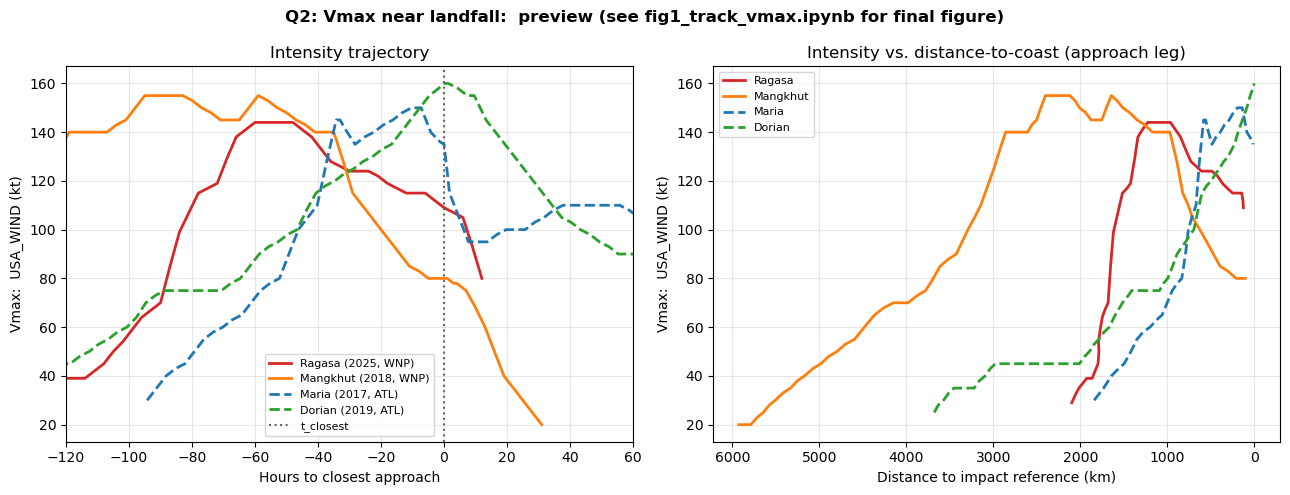

Saved preview to figures/q2_preview.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Vmax vs. hours-to-impact
ax = axes[0]
for key in STORM_ORDER:
    df_t = tracks.get(key)
    if df_t is None:
        continue
    meta = STORMS[key]
    ax.plot(df_t['hours_to_impact'], df_t['USA_WIND'],
            color=meta['color'], linestyle=meta['linestyle'],
            linewidth=2, label=f"{meta['name']} ({meta['year']}, {meta['basin']})")
ax.axvline(0, color='0.4', linestyle=':', label='t_closest')
ax.set_xlim(-120, 60)
ax.set_xlabel('Hours to closest approach')
ax.set_ylabel('Vmax:  USA_WIND (kt)')
ax.set_title('Intensity trajectory')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Right: Vmax vs. distance-to-coast
ax2 = axes[1]
for key in STORM_ORDER:
    df_t = tracks.get(key)
    if df_t is None:
        continue
    meta = STORMS[key]
    # Only the approach leg (hours_to_impact < 0)
    approach = df_t[df_t['hours_to_impact'] <= 0]
    ax2.plot(approach['dist_km'], approach['USA_WIND'],
             color=meta['color'], linestyle=meta['linestyle'],
             linewidth=2, label=f"{meta['name']}")
ax2.set_xlabel('Distance to impact reference (km)')
ax2.set_ylabel('Vmax:  USA_WIND (kt)')
ax2.set_title('Intensity vs. distance-to-coast (approach leg)')
ax2.invert_xaxis()  # 0 = impact, storms approach from right
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.suptitle('Q2: Vmax near landfall:  preview (see fig1_track_vmax.ipynb for final figure)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'q2_preview.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved preview to figures/q2_preview.png')